# Brent Oil Price: Exploratory Data Analysis

**Project:** Change Point Analysis and Statistical Modeling of Time Series Data
Time Series EDA and Change Point Model Understanding

This notebook:
1. Loads and cleans the Brent oil daily price dataset (1987–2022)
2. Visualizes the raw price series and log returns
3. Investigates trend, stationarity, and volatility, and discusses how these properties inform the modeling choices for Task 2
4. Explains the purpose, mechanics, and expected outputs of Bayesian change point models


## 1. Setup & Data Loading

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

from data_loader import load_brent_prices, load_events

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True


Matplotlib is building the font cache; this may take a moment.


In [2]:
DATA_PATH = "../data/raw/BrentOilPrices.csv"
EVENTS_PATH = "../data/key_events_verified.csv"

df = load_brent_prices(DATA_PATH)
events = load_events(EVENTS_PATH)

print(f"Loaded {len(df):,} daily price observations")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.head()


Loaded 9,011 daily price observations
Date range: 1987-05-20 to 2022-11-14


,Price,LogPrice,LogReturn
Date,,,
1987-05-20,18.63,2.924773,NaN
1987-05-21,18.45,2.915064,-0.009709
1987-05-22,18.55,2.920470,0.005405
1987-05-25,18.60,2.923162,0.002692
1987-05-26,18.63,2.924773,0.001612


The loader (`src/data_loader.py`) handles two date formats present in the
raw file (`20-May-87` style for earlier rows, `Nov 08, 2022` style for later
rows), coerces the price column to numeric, and raises clear errors on a
missing file, missing columns, or an empty/unparseable dataset. It also
computes `LogPrice` and `LogReturn` (the first difference of log price,
i.e. the daily log return) up front, since both are used throughout this
notebook.

## 2. Raw Price Series

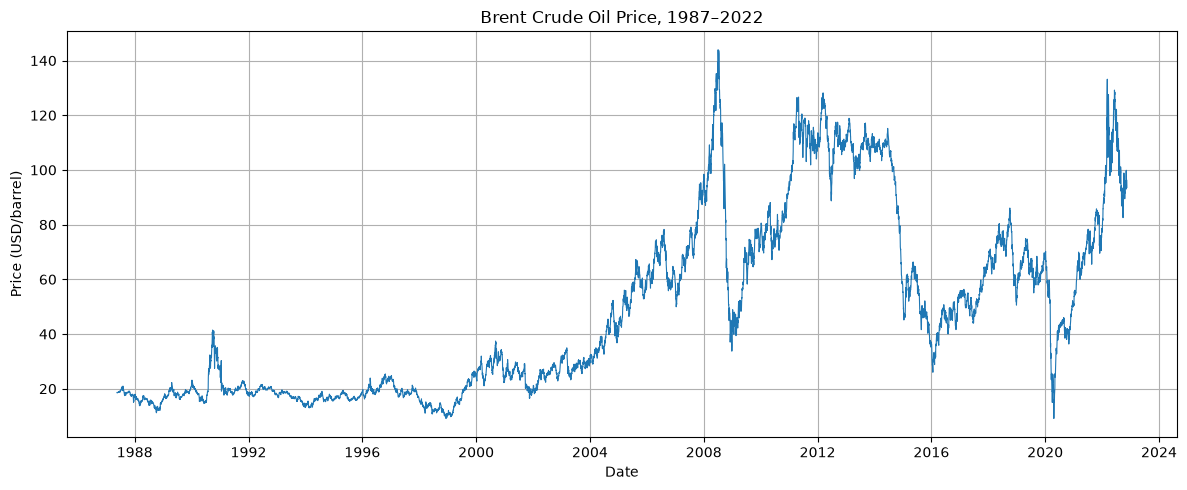

In [3]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Price"], linewidth=0.8, color="#1f77b4")
ax.set_title("Brent Crude Oil Price, 1987–2022")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD/barrel)")
plt.tight_layout()
plt.savefig("../notebooks/fig_raw_price.png", dpi=100)
plt.show()


**Observations:**
- The series shows a clear long-run **upward trend** with several sharp
  regime shifts rather than smooth, gradual growth, consistent with prices
  reacting abruptly to supply/demand shocks and geopolitical events.
- Distinct volatility regimes are visible: relatively calm periods (e.g.
  the 1990s) versus highly volatile stretches (2008 financial crisis, 2014-16
  price collapse, 2020 COVID crash).
- The series is visibly **non-stationary** its mean and variance are not
  constant over time, which has direct implications for modeling (see
  Section 4).

## 3. Log Returns

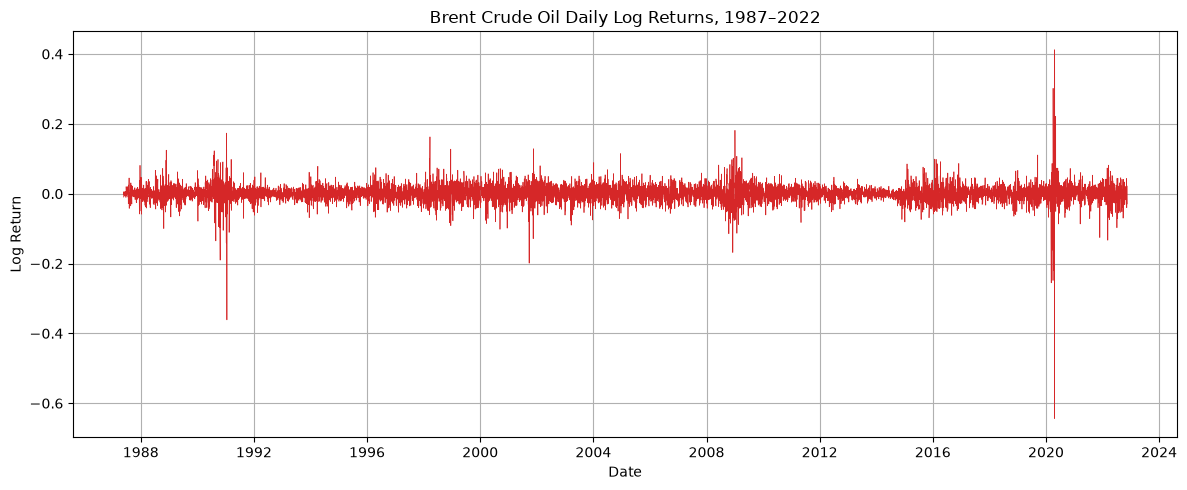

In [4]:
fig, ax = plt.subplots()
ax.plot(df.index, df["LogReturn"], linewidth=0.5, color="#d62728")
ax.set_title("Brent Crude Oil Daily Log Returns, 1987–2022")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
plt.tight_layout()
plt.savefig("../notebooks/fig_log_returns.png", dpi=100)
plt.show()


**Observations:**
- Log returns fluctuate around a roughly constant mean near zero, unlike
  the raw price series, a first visual sign of stationarity.
- **Volatility clustering** is clearly visible: large swings (e.g. 2008,
  early 2020) are followed by more large swings, and calm periods by more
  calm periods. This is a hallmark of financial/commodity return series and
  violates the constant-variance assumption of the simplest models.

## 4. Trend, Stationarity & Volatility Analysis

### 4.1 Stationarity: Augmented Dickey-Fuller Test

In [6]:
adf_price = adfuller(df["Price"].dropna())
adf_logret = adfuller(df["LogReturn"].dropna())

print("ADF Test: Raw Price")
print(f"  Test statistic: {adf_price[0]:.4f}")
print(f"  p-value:        {adf_price[1]:.4f}")
print()
print("ADF Test: Log Returns")
print(f"  Test statistic: {adf_logret[0]:.4f}")
print(f"  p-value:        {adf_logret[1]:.6e}")


ADF Test: Raw Price
  Test statistic: -1.9939
  p-value:        0.2893

ADF Test: Log Returns
  Test statistic: -16.4271
  p-value:        2.498580e-29


**Interpretation:**
- **Raw price:** ADF p-value ≈ 0.29. We **fail to reject** the null
  hypothesis of a unit root. The raw price series is **non-stationary**.
- **Log returns:** ADF p-value ≈ 2.5e-29. We **strongly reject** the null
  hypothesis. Log returns **are stationary**.

This confirms the visual impression from Sections 2–3 and is the standard
result for financial/commodity price series, prices themselves trend and
drift, but returns (or log returns) tend to be stationary.

### 4.2 Volatility Clustering: Rolling Standard Deviation

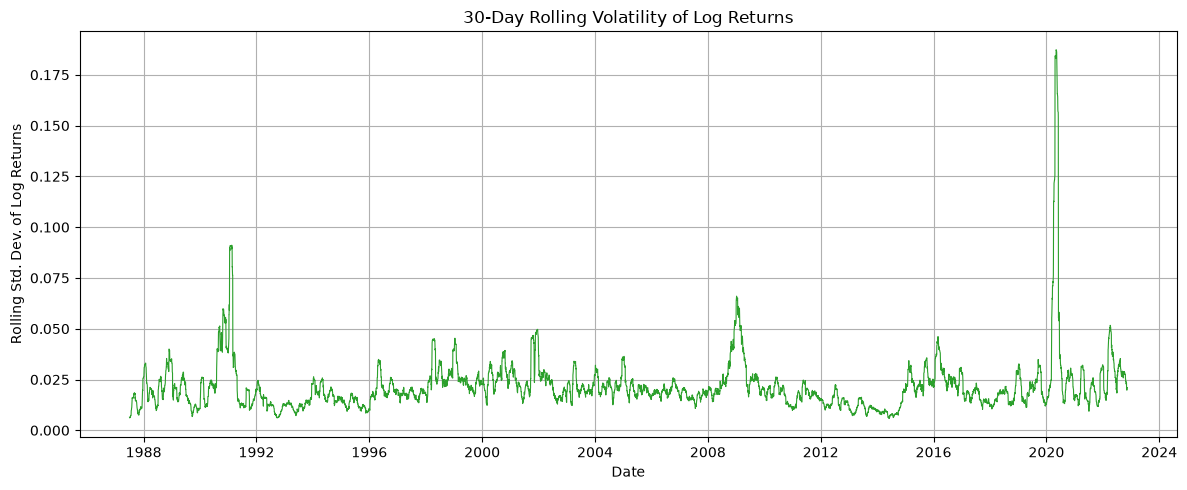

In [7]:
rolling_vol = df["LogReturn"].rolling(window=30).std()

fig, ax = plt.subplots()
ax.plot(df.index, rolling_vol, linewidth=0.8, color="#2ca02c")
ax.set_title("30-Day Rolling Volatility of Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Std. Dev. of Log Returns")
plt.tight_layout()
plt.savefig("../notebooks/fig_rolling_volatility.png", dpi=100)
plt.show()


**Observations:**
- Volatility is clearly **time-varying**, with sharp spikes around known
  shocks (2008-09 financial crisis, late 2014 OPEC decision, 2020 COVID/price
  war). This is further evidence against a simple constant-variance model.
- Periods of low, stable volatility alternate with sudden bursts, the
  "volatility clustering" pattern typical of financial time series (formally
  modeled by GARCH-family models, though outside this project's scope).

### 4.3 How These Properties Inform Modeling Choices

- **Model on log returns, not raw price.** Because the raw price series is
  non-stationary while log returns are stationary, the Bayesian change point
  model in Task 2 should be applied primarily to **log returns** (or an
  explicitly detrended price series). Fitting a constant-mean model directly
  to raw non-stationary prices would produce misleading change points driven
  by trend rather than genuine structural breaks.
- **A single change point is a simplification.** The visible volatility
  clustering and multiple distinct regimes suggest the price/return series
  may contain **more than one** structural break over 1987–2022. The initial
  model (Task 2) will fit a single change point as a baseline; extending to
  multiple change points is a natural next step.
- **Volatility itself may shift, not just the mean.** Because variance
  changes over time, a natural extension beyond a mean-shift model is a
  change point model that also allows the **variance/volatility** to shift
  at the break point, not just the mean.

## 5. Change Point Models: Purpose & Expected Outputs

### What is a change point model?

A change point model is a statistical method for detecting the point(s) in
time at which the underlying statistical properties of a time series
(e.g. its mean, variance, or trend) shift abruptly. Rather than assuming a
single set of parameters governs the entire series, the model allows for
one or more distinct "regimes," each with its own parameters, separated by
one or more change points.

### Why use one here?

Brent oil prices are affected by discrete, often sudden events, wars,
OPEC policy decisions, sanctions, financial crises, that can shift the
price level or volatility abruptly rather than gradually. A change point
model gives a **statistically principled way to detect exactly when** such
shifts occurred in the data itself, which can then be compared against the
researched events dataset (`data/key_events_verified.csv`) to generate
data-informed hypotheses about likely causes.

### The Bayesian approach used in Task 2 (conceptual outline)

- A **switch point** `tau` is treated as an unknown parameter with a prior
  distribution (e.g. discrete uniform over all time indices).
- Separate parameters are defined for the period **before** `tau` and the
  period **after** `tau` (e.g. two means, μ₁ and μ₂).
- A switching function (`pm.math.switch` in PyMC) selects the correct
  parameter for each time index based on whether it falls before or after
  `tau`.
- MCMC sampling produces a full **posterior distribution** over `tau`
  (and over μ₁, μ₂), rather than a single point estimate, giving a
  natural measure of uncertainty about exactly when the change occurred.

### Expected outputs

- **Identified change point date(s):** the posterior distribution of `tau`,
  typically summarized by its most probable value and a credible interval.
- **New parameter values:** posterior distributions for the "before" and
  "after" parameters (e.g. mean price/return, volatility), allowing
  probabilistic statements like *"there is a 95% probability the mean
  shifted from X to Y."*
- **Quantified impact:** the magnitude and direction of the shift, which
  can be reported alongside the associated real-world event.

### Limitations

- **Correlation in time ≠ causation.** A detected change point occurring
  near a known event is a **statistical association**, not proof that the
  event *caused* the shift. Other unobserved factors may coincide in time.
- **Single change point assumption** (Section 4.3) may under-fit a series
  with multiple structural breaks.
- **Sensitivity to model specification** e.g. whether the model targets
  the mean, variance, or both, and whether it's applied to price or log
  returns, will affect which change points are detected.

## 6. Summary

- Brent oil prices (1987-2022) show a non-stationary raw price series with
  a long-run upward trend and several distinct regimes.
- Log returns are stationary (confirmed by ADF test) and exhibit clear
  volatility clustering.
- These properties motivate modeling **log returns** in Task 2, starting
  with a single Bayesian change point model on the mean, with volatility
  modeling and multiple change points as natural extensions.
- Change point models will identify statistically-supported break dates,
  which will then be cross-referenced against `data/key_events_verified.csv`
  to form (not prove) hypotheses about real-world drivers.